Suppose $Y$ is a scalar response variable and $X = \left[ x_1, x_2,...,x_p\right ]^T$ is a vector of $p$ predictor variables, where $T$ means transpose. The single index model has the form
\begin{equation}
Y = m(\theta^T X) + \epsilon
\end{equation}
where $\theta$ is a unit index vector of p unknown parameters, sometimes called orientation, $m$ is an unknown link function, and $\epsilon$ is a random error satisfying $E(\epsilon|X) = 0$ almost surely.

SIM_NNG is a convex problem
$$\begin{equation}\label{equ:2.5}	
\min \limits_{\beta_k > 0, k =1,\dots,p}
\sum \limits_{j = 1}^{n} \sum \limits_{i = 1}^{n}\left[ y_i - a_j -  b_j \beta^T(z_i - z_j)\right]^2 \omega_{ij} + \lambda \sum \limits_{j=1}^{n} \left|b_j\right| \sum \limits_{k=1}^{p}\beta_k,
\end{equation} 	$$
such that $\beta^T(\mbox{diag}(\theta^{0}))^2\beta=1$

In [ ]:
import numpy as np
from scipy.stats import norm
from sklearn.linear_model import LinearRegression, Lasso, lasso_path
import matplotlib.pyplot as plt
## non negative garrotte can be transform as a non negative lasso problem
def non_negative_garrotte(X, y, alpha, tol=0.001):
    shrink_coef = Lasso(alpha=alpha, fit_intercept=False,
                        positive=True, normalize=False,
                        tol=tol).fit(X, y).coef_
    return shrink_coef

def f2(x):
    return np.linalg.norm(x)

def my_substract(x, y):
    return x - y

def threshold(x, tau):
    if x > tau:
        s = x - tau
    elif x < - tau:
        s = x + tau
    else:
        s = 0
    return s

###############################rule of thumb for choose bandwidth h
def choose_h(data_x, sc, p):
    n = np.shape(data_x)[0]
    h = (4 / (2 * p + 1) / n) ** (1 / (p + 4)) * np.median(np.std(data_x, 0)) * sc
    return h


############################### use the high dimensional normal kernel for the caculation of weight function in OPG
def weight_function_OPG(data_x_train, data_x_test, h):
    X_ = np.apply_along_axis(my_substract, 1, data_x_test, data_x_train)
    X_A = np.apply_along_axis(f2, 2, X_ / h)
    K = norm.pdf(X_A)
    sum_weight = np.sum(K, 0)
    W = K / sum_weight
    return W


def weight_function(data_x_train, data_x_test, h, theta):
    X_ = np.apply_along_axis(my_substract, 1, data_x_test, data_x_train)
    X_A = np.dot(X_, theta / h)
    K = norm.pdf(X_A)
    sum_weight = np.sum(K, 0)
    W = K / sum_weight
    return W

def LOSS(data_x_train, data_y_train, W, a, b, theta):
    n, p = np.shape(data_x_train)
    Y_ij = np.zeros((n, n))
    X_ = np.apply_along_axis(my_substract, 1, data_x_train, data_x_train)
    theta_X_ = np.dot(X_, theta)
    for i in range(n):
        Y_ij[i,] = data_y_train[i] - a
    b_theta_XX_ = np.dot(theta_X_, np.diag(b))
    error = np.sum( (np.sqrt(W) * Y_ij - np.sqrt(W) * b_theta_XX_) ** 2 ) / (2 * n ** 2)
    return error

#### The MAVE
class MAVE:
    def __init__(self, x, y):
        self.x = x
        self.y = y
        self.n = x.shape[0]
        self.p = x.shape[1]
        self.h_opg = choose_h(self.x, 2, self.p)
        self.h = choose_h(self.x, 1, 1)
        self.W_opg = weight_function_OPG(self.x, self.x, self.h_opg)

    #         self.W = weight_function(self.x, self.x, self.h_opg, theta)
    ###############use the OPG  as the initial estimator in the iterative algrithm for MAVE
    def OPG(self):
        y_tilde = np.dot(self.W_opg.T, self.y)
        X_tilde = np.dot(self.W_opg.T, self.x)
        Y_star = np.empty((self.n, self.n))
        for i in range(self.n):
            Y_star[i,] = self.y[i] - y_tilde
        X_ = np.apply_along_axis(my_substract, 1, self.x, X_tilde)
        W_X = X_ * self.W_opg[:, :, np.newaxis]
        W_Y = Y_star * self.W_opg
        beta = np.empty((self.n, self.p))
        for i in range(self.n):
            model = LinearRegression()
            model.fit(W_X[i,], W_Y[i,])
            beta[i,] = model.coef_
        opg = 0
        for i in range(self.n):
            opg += np.outer(beta[i,], beta[i,])
        eigvalue, eigvector = np.linalg.eig(opg)
        ind = np.argmax(eigvalue)
        theta_OPG = eigvector[:, ind]
        return theta_OPG

    #################### fixed theta caculation for b ,it has the close form
    def min_b_MAVE(self, theta):
        h = choose_h(self.x, 1, 1)
        W = weight_function(self.x, self.x, h, theta)
        y_tilde = np.dot(W.T, self.y)  # array(n,1)
        X_tilde = np.dot(W.T, self.x)  # array(n,p)= [x_1_tilde,.....,x_n_tilde]
        R = [np.dot(((self.y - y_tilde[j]) * W[:, j]).T, np.dot(self.x - X_tilde[j, :], theta)) for j in range(self.n)]
        S = [np.sum((np.sqrt(W[:, j]) * np.dot(self.x - X_tilde[j, :], theta)) ** 2) for j in range(self.n)]
        b = np.array(R) / np.array(S)
        return b

    #################### fixed b caculation for theta, it's a weighted linear regression problem
    def min_theta_MAVE(self, b, theta):
        W = weight_function(self.x, self.x, self.h, theta)
        y_tilde = np.dot(W.T, self.y)  # array(n,1)
        X_tilde = np.dot(W.T, self.x)
        W = np.sqrt(W)
        Y_star = np.empty((self.n, self.n))
        for i in range(self.n):
            Y_star[i,] = self.y[i] - y_tilde
        Y_star_W = Y_star * W
        vec_y_ij = Y_star_W.reshape(self.n ** 2)
        X_ = np.apply_along_axis(my_substract, 1, self.x, X_tilde)
        X_b = np.einsum("ij...,j->ij...", X_, b)
        W_X_b = (X_b * W[:, :, np.newaxis]).reshape(self.n ** 2, self.p)
        model = LinearRegression()
        model.fit(W_X_b, vec_y_ij)
        theta_hat = model.coef_
        return theta_hat

    #################### iterative algrithm for the MAVE
    def adp_MAVE(self, maxepochs=500, epsilon=1e-3):
        epochs = 0
        theta_init = self.OPG()
        b = self.min_b_MAVE(theta_init)
        theta = theta_init
        while (epochs <= maxepochs):
            theta_new = self.min_theta_MAVE(b,theta)
            norm_ = np.linalg.norm(theta_new, 2)
            theta_new = theta_new / norm_
            b_new = self.min_b_MAVE(theta_new)
            #         print("the b_error:",np.linalg.norm(b_new - b, 2))
            #         print("the theta_error:", np.linalg.norm(theta_new - theta, 2))
            if (np.linalg.norm(theta_new - theta, 2) < epsilon) & (
                    np.linalg.norm(b_new - b, 2) < epsilon):  ###if reach the stop criterion break
                theta = theta_new
                b = b_new
                break
            theta = theta_new
            b = b_new
            epochs += 1

        if (epochs < maxepochs):
            print("MAVE converge")
        else:
            print("MAVE not converge")
        theta_MAVE = theta
        b_MAVE = b
        W = weight_function(self.x, self.x, self.h, theta_MAVE)
        a_MAVE = np.dot(W.T, self.y) - b_MAVE * np.dot(np.dot(W.T, self.x) - self.x, theta_MAVE)
        RSS_MAVE = LOSS(self.x, self.y, W, a_MAVE, b_MAVE, theta_MAVE)
        return [theta_MAVE, a_MAVE,b_MAVE, RSS_MAVE]

############# sim-nng method
class sim_nng:
    def __init__(self, x, y, theta_init, lambd):
        self.x = x
        self.y = y
        self.n = x.shape[0]
        self.p = x.shape[1]
        self.theta_init = theta_init
        self.lambd = lambd
        self.h = choose_h(self.x,1,1)
    #################### fixed C then caculate for b
    def min_b(self, C):
        theta_hat = self.theta_init * C
        W = weight_function(self.x, self.x, self.h, self.theta_init)
        lambd_star = self.lambd * np.sum(C)
        y_tilde = np.dot(W.T, self.y)
        X_tilde = np.dot(W.T, self.x)
        R = [np.dot(((self.y - y_tilde[j]) * W[:, j]).T, np.dot(self.x - X_tilde[j, :], theta_hat)) for j in
             range(self.n)]
        S = [np.sum((np.sqrt(W[:, j]) * np.dot(self.x - X_tilde[j, :], theta_hat)) ** 2) for j in range(self.n)]
        b = np.array([threshold(R[j], lambd_star / 2) / S[j] for j in range(self.n)])
        return b
    #################### fixed b caculate for C
    def min_C(self, b, theta ):
        lambd_star = self.lambd / (2 * self.n**2) * np.sum(np.abs(b))
        h = choose_h(self.x, 1, 1)
        W = weight_function(self.x, self.x, self.h, theta)
        y_tilde = np.dot(W.T, self.y)  # array(n,1)
        X_tilde = np.dot(W.T, self.x)
        W = np.sqrt(W)
        Y_star = np.empty((self.n, self.n))
        for i in range(self.n):
            Y_star[i,] = self.y[i] - y_tilde
        Y_star_W = Y_star * W
        vec_y_ij = Y_star_W.reshape(self.n ** 2)
        X_ = np.apply_along_axis(my_substract, 1, self.x, X_tilde)
        theta_X = self.theta_init * X_
        theta_X_b = np.einsum("ij...,j->ij...", theta_X, b)
        W_theta_X = theta_X_b * W[:, :, np.newaxis]
        vec_theta_X = W_theta_X.reshape(self.n**2, self.p)
        if lambd_star == 0:
            model = LinearRegression()
            model.fit(vec_theta_X, vec_y_ij)
            C = model.coef_
        else:
            C = non_negative_garrotte(vec_theta_X, vec_y_ij, lambd_star, tol=0.001)
        return np.array(C)
    #################### iterative algrithm for caculate for sim-nng estimator
    def adp_sim_nng_naive(self,maxepochs=500, epsilon=1e-3):
        epochs = 0
        C = np.ones(self.p)
        b = self.min_b(C)

        while (epochs <= maxepochs):
            theta = self.theta_init * C
            if np.sum(b) == 0:  ##if b shrinkaged to be zeros, then C is not identifiable
                break
            C_new = self.min_C(b,theta)
            b_new = self.min_b(C_new)
            norm_ = np.linalg.norm(C_new * self.theta_init, 2)
            C_new = C_new / norm_
            b_new = b_new * norm_
            theta_new = self.theta_init * C_new
            if (np.linalg.norm(theta_new - theta, 2) < epsilon) & (np.linalg.norm(b_new - b, 2) < epsilon): ###if reach the stopping criterion then break loop
                C = C_new
                b = b_new
                break
            C = C_new
            b = b_new
            epochs += 1
        theta_nng = self.theta_init * C
        b_nng = b
        W = weight_function(self.x, self.x, self.h, theta_nng)
        a_nng = np.dot(W.T, self.y) - b * np.dot(np.dot(W.T, self.x) - self.x, theta_nng)
        RSS_nng = LOSS(self.x, self.y, W, a_nng, b_nng, theta_nng)
        return [theta_nng, a_nng, b_nng, RSS_nng]






We give a toy experiment as follow to illustrate SIM-NNG method

Let’s implement from scratch the SIM-NNG estimate to get a feeling of how it works in practice.
we define a sparse oreintation $\theta = [1,-1,2,-0.5,0,\dots,0] \in R^{20 \times 1}$, and the link function is $m(x) = x^2 cosx$, $x$ sample from $U(-1,1)$,we use the MAVE and SIM-NNG to fit this curve

MAVE not converge


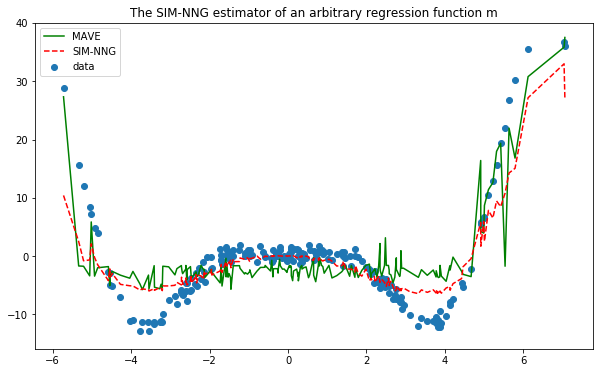

In [41]:
if __name__ == "__main__":
    
    def g(x):
        theta = np.zeros(20)
        theta[0:4] = [1, -1, 2, -0.5]
        x = np.dot(theta.T,x)
        return [x**2*np.cos(x),x] 

    class Model:
        def __init__(self, N):
            theta = np.zeros(20)
            theta[0:4] = [1, -1, 2, -0.5]
            self.theta = theta
            p = len(self.theta)
            X = np.zeros((N, p))
            for i in range(N):
    #             X[i,] = np.random.normal(1,2,p)
                X[i,] = np.random.uniform(-2, 2, p)

            #           self.X = np.random.multivariate_normal(np.zeros(p), np.identity(p), N)
            sigma = 0.9
            self.eps = sigma * np.random.normal(0, 1, N)
            self.g_X = np.apply_along_axis(g, 1, X)[:,0]
            self.theta_x = np.apply_along_axis(g, 1, X)[:,1]
            #         self.g_X = g(self.X.T)
            self.Y = self.g_X + self.eps
            self.X = (X - np.mean(X, 0)) / np.std(X, 0)
            self.p = p


    model = Model(200)
    x = model.X
    y = model.Y
    g_x = model.g_X
    theta_x = model.theta_x

    mave = MAVE(x,y)
    mave.OPG()
    r = mave.adp_MAVE(maxepochs = 50, epsilon=1e-3)

    nng = sim_nng(x, y, r[0], 0.12)
    r2 = nng.adp_sim_nng_naive(maxepochs=50, epsilon=1e-3)

    zipped = zip(theta_x,r[1])
    re = zip(*sorted(zipped, key = lambda x : x[0]))
    thetax, r_1 = [list(x) for x in re]

    zipped = zip(theta_x,r2[1])
    re = zip(*sorted(zipped, key = lambda x : x[0]))
    thetax, r_2 = [list(x) for x in re]

    zipped = zip(theta_x,y)
    re2 = zip(*sorted(zipped, key = lambda x : x[0]))
    thetax, y = [list(x) for x in re2]


    plt.figure(figsize = (10,6))
    # plt.scatter(np.arange(100),y)
    # plt.plot(np.arange(100),r2[1],color = 'r')
    plt.plot(thetax,r_1,color = 'g')
    plt.plot(thetax,r_2,'r--')
    # plt.plot(g,r[1],color = 'g')
    plt.scatter(thetax,y)
    plt.legend(['MAVE','SIM-NNG','data'])
    plt.title('The SIM-NNG estimator of an arbitrary regression function m')
    plt.show()


With an appropriate $\lambda$ has been choosen, we find the SIM-NNG fit the curve better than the MAVE, SIM-NNG is smoother than MAVE, especially in the bound of curve, it's more stable than MAVE and hardly influenced by the noise data point, the good property of SIM-NNG can attribute to identify the useful estimator 

In [42]:
theta = np.zeros(20)
theta[0:4] = [1, -1, 2, -0.5]
theta_true = theta/np.sqrt(np.sum(theta**2))
print('SIM NNG estimator of the oreintation theta is:\n$',r2[0])
print('The true oreintation theta is:\n$',theta_true)

SIM NNG estimator of the oreintation theta is:
$ [ 0.4320156  -0.38152659  0.78648369 -0.21298778 -0.0120582  -0.01608236
 -0.         -0.         -0.         -0.          0.         -0.
  0.05895372  0.          0.         -0.          0.         -0.
 -0.          0.        ]
The true oreintation theta is:
$ [ 0.4 -0.4  0.8 -0.2  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
  0.   0.   0.   0.   0.   0. ]
